# Preliminaries

In [1]:
from dolfin import *
from ufl import indices, Jacobian, Min, Max, And, shape, replace
import numpy as np
import sys, os, pygmsh, gmsh, meshio, time

In [2]:
# ploting customizations
from matplotlib import pyplot as plt
from matplotlib import tri, colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d
size=18
params = {'legend.fontsize': size*0.75,
        #   'figure.figsize': (20,8),
          'text.usetex': True,
          'text.latex.preamble': r'\usepackage{mathrsfs}',
        #   'mathtext.fontset': 'stix',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline

## Credit

Based heavily on [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi) from David Kamensky's [MAE 207: FEA for coupled problems](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master) course at UC San Diego.

Rewrite by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot):
- restricting to _steady flows_, 
- making solver monolithic, 
- treating pressure inlet as Neumann BC, 
- switching meshing to gmsh, 
- converting to notebook format, 
- adding steady analytical solution comparisons, 
- various other small improvements.

## Introduction

Sketch of the geometry and notation.

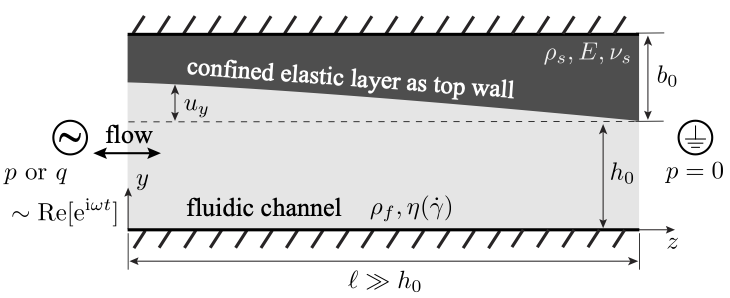

**TODO:** Update constant $\mu_f$ below to $\eta(\dot{\gamma})$ for shear-thinning.

# Problem setup

## Simulation settings

### Data storage

In [3]:
# If the folder does not exist, create it.
# I'm using a folder that will not get synced to GitHub.
DataFolder = "not-ready-for-github/simulation_output/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output/


### Algorithmic settings

Shouldn't require changing.

In [4]:
mesh_approach   = "BLENDED" # mesh elasticity approach; "SPLIT" or "BLENDED" 
                            # should be equivalent but BLENDED seems more stable

LSIC            = True      # Least-squares incompressibility stabilization for fluid
BACKFLOW_STAB   = True      # Backflow stabilization for fluid
SUPG            = False     # Streamline Upwind Petrov-Galerkin stabilization for fluid

FLUID_MODE_ONLY = False     # A debugging option to run only the fluid problem   

print("============================ INFO ===========================")
print(f"Mesh elasticity approach: {mesh_approach}")
print(f"LSIC stabilization:       {'ON' if LSIC else 'OFF'}")
print(f"Backflow stabilization:   {'ON' if BACKFLOW_STAB else 'OFF'}")
print(f"SUPG stabilization:       {'ON' if SUPG else 'OFF'}")
if FLUID_MODE_ONLY:
    print("-------------------------------------------------------------")
    print("WARNING: Running in FLUID MODE ONLY (no solid coupling)")
print("=============================================================")

============================ INFO ===========================
Mesh elasticity approach: BLENDED
LSIC stabilization:       ON
Backflow stabilization:   ON
SUPG stabilization:       OFF


### Parameters defining domain geometry

In [5]:
# Dimensions:
b0 = 0.01
h0 = b0
l  = 75*h0 #50

# Desired resolution of mesh:
N = 60 # 600
# Refine near inlet in SOLID domain only?
inlet_refinement_solid_only = False
inlet_refinement = 0.5 # 1 = no refinement, 1/() times finer
# Refinement near fluid-solid interface
interface_refinement = 0.33 # 1 = no refinement, 1/() times finer

### Material properties (dimensional)

In [6]:
# Elastic solid's properties:
E_s    = 7e+5                           # Young's modulus
nu_s   = 0.45                           # Poisson ratio
mu_s   = Constant(E_s/(2*(1+nu_s)))     # Shear modulus
K      = Constant(E_s/(3*(1-2*nu_s)))   # Bulk modulus
rho_s0 = Constant(1e4)

# Viscous fluid properties to yield desired dimensionless numbers,
# based on dynamic similarity:
rho_f = Constant(0.5)
mu_f  = Constant(1.0)
nu_f  = mu_f/rho_f                      # Kinematic viscosity

### Boundary conditions (analyical)

In [7]:
# Steady pressure BC:
p_amp = Constant(2e5)
p_in  = Expression("p0", p0=float(p_amp), degree=1)

# Steady flow-rate BC:
q_amp = Constant(0.025)
v_in  = Expression(("x[1] < h0 + eps ? 6*(q0/h0)*(x[1]/h0)*(h0-x[1])/h0 : 0.0", "0.0"),
                   q0=float(q_amp), h0=float(h0), eps=DOLFIN_EPS, degree=2)

# Choose flow or pressure controlled BC:
FLOW_OR_PRESSURE = "FLOW"  # "FLOW" or "PRESSURE"
print(f"Using {FLOW_OR_PRESSURE}-controlled BC.")

Using FLOW-controlled BC.


### Dimensionless numbers

In [8]:
# Adjust scales for either flow rate or pressure control BC:
if FLOW_OR_PRESSURE == "FLOW":
    q_c = q_amp
    v_c = q_c/h0
    p_c = mu_f*q_c*l/h0**3
    dp_rigid = 12.0*float(p_c)
    q_rigid = float(q_c)    
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c = p_amp
    q_c = (p_c/l)*(h0**3/mu_f)
    v_c = q_c/h0
    dp_rigid = float(p_c)
    q_rigid = float(q_c/12.0)    
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

In [9]:
epsilon_f = h0/l                                             # Fluid (inverse) aspect ratio
epsilon_s = b0/l                                             # Solid (inverse) aspect ratio
C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s/l**2)    # Incompressible foundation compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*(b0/mu_s)                      # Winkler foundation compliance
C_H = (nu_s-1/4)/(1-nu_s)*(b0**2/mu_s/l)                     # Horizontal component compliance
theta = float(C_I/C_w)
vartheta = float(C_H/C_w)
beta = float(p_c/(h0/C_w))                                   # Compliance number
Re = float(epsilon_f * rho_f * v_c * h0/mu_f)                # Reynolds number
#Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/mu_f**2)      

print("============================ INFO ===========================")
print(f"ε_f = {epsilon_f:.5f}")
print(f"ε_s = {epsilon_s:.5f}")
print(f"θ   = {theta:.5f}")
print(f"β   = {beta:.5f} (compliance #)")
print(f"εRe = {Re:.5f} (Reynolds #)")
print("=============================================================")

============================ INFO ===========================
ε_f = 0.01333
ε_s = 0.01333
θ   = 0.00039
β   = 0.00706 (compliance #)
εRe = 0.00017 (Reynolds #)


## Analytical solutions: for comparisons etc

### Rigid channel

Implementing the steady 2D channel flow solution.

In [10]:
# Note that "x" in v_in and/or p_in is really "y" in the kinematics,
# but, the mesh problem has a zero Dirichlet BC on the inflow boundary, 
# forcing x = y there.

# x[1] < h0 is needed if we want to evaluate this 
# over the whole Omega domain as an initial condition
p_rigid = Expression("x[1] < h0 + eps ? (dp/L)*(L-x[0]) : 0.0", 
                     dp=float(p_amp), h0=float(h0), L=float(l), eps=DOLFIN_EPS, degree=1)
v_rigid = v_in

p_rigid.dp = float(dp_rigid)
v_rigid.q0 = float(q_rigid)

### Compliant channel

Implenting Eq. (41) and related results from 

1. "[Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits](https://dx.doi.org/10.1088/1361-648X/ac327d)" (preprint [arXiv:2106.07164](https://arxiv.org/abs/2106.07164)) for the flow-controlled case, 

2. "[Oscillatory flows in compliant conduits at arbitrary Womersley number](https://dx.doi.org/10.1103/PhysRevFluids.8.124102)" (preprint [arXiv:2304.00543](https://arxiv.org/abs/2304.00543)) for the pressure-controlled case (see Eq. (A.2) and related results).

In [11]:
if FLOW_OR_PRESSURE == "FLOW":
   p_sh = Expression("pc/b*(pow(1 + 48.0*b*(1.0-x[0]/L),0.25) - 1.0)", 
                     pc=float(p_c), b=float(beta), L=float(l), degree=1)
   q_sh = q_sh_in = q_sh_out = q_rigid
elif FLOW_OR_PRESSURE == "PRESSURE":
   p_sh = Expression("pc/b*(pow(pow(1.0+b,4.0) - ((pow(1.0+b,4.0)-1.0)*x[0]/L), 0.25) - 1.0)", 
                     pc=float(p_c), b=float(beta), L=float(l), degree=4)
   # now the flow rate is found from the pressure gradient at x = 0 and the rigid v profile
   dp_shdz0 = -(p_c/l)*((2+beta)*(2+2*beta+beta**2))/(4*(1+beta)**3)
   dp_shdzL = -(p_c/l)*((-1+(1+beta)**4))/(4*beta)
   # taking into account wall deformation h0 -> h0+Cw p, q = const again
   q_sh = q_sh_in = q_sh_out = (-dp_shdz0)*((h0+C_w*p_sh(0))**3/mu_f)/12.0
   #q_sh_out = (-dp_shdzL)*((h0+C_w*p_sh(l))**3/mu_f)/12.0
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

## Domain and mesh

Gmsh-based geometry & mesh.

In [12]:
# Generate custom mesh with local refinements:
from build_mesh_with_gmsh import build_mesh_with_gmsh

xdmf_path = build_mesh_with_gmsh(N,
                                 [0.0, l, 0.0, h0+b0, b0],
                                 DataFolder+"fsi_rect",
                                 inlet_refinement=inlet_refinement, 
                                 inlet_refinement_solid_only=inlet_refinement_solid_only,
                                 interface_refinement=interface_refinement)

# Load mesh back into dolfin from XDMF:
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Mesh-derived quantities:
d   = mesh.geometry().dim()
n_y = FacetNormal(mesh)
I   = Identity(d)

Info    : Found interface curve 4: x = [-0.000000, 0.750000], y = 0.010000                                  
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.0844638s, CPU 0.126272s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0202929s, CPU 0.027158s)
Info    : 472 nodes 1094 elements
Info    : Writing 'not-ready-for-github/simulation_output/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output/fsi_rect.msh'



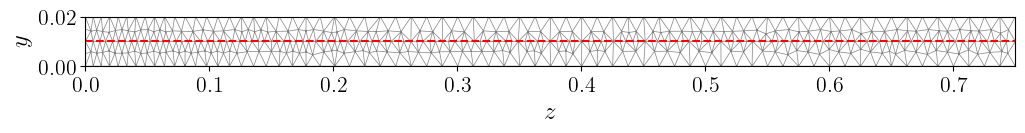

In [ ]:
# Visualize the mesh real quick:
plot(mesh)
plt.gca().lines[0].set_linewidth(0.5)
plt.gca().set_aspect(2/1)
plt.gca().set_xlim(0, l)
plt.gca().set_xlabel("$z$")
plt.gca().set_ylabel("$y$")
plt.gca().set_ylim(0, h0+b0)
plt.gcf().set_size_inches(12, 6)
plt.plot(np.linspace(0, l, 10),np.ones(10)*(h0+b0)/2,linestyle='--', color='red')
plt.show()

In [181]:
# Define subdomains for use in boundary condition definitions:
class Wall_b(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[1], 0.0))

class Wall_t(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[1], h0+b0))

class Wall_l(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], 0.0)
                and (x[1] > h0 - DOLFIN_EPS))

class Wall_r(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], l)
                and (x[1] > h0 - DOLFIN_EPS))

class Inflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], 0.0)
                and (x[1] < h0 + DOLFIN_EPS))

class Outflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], l)
                and (x[1] < h0 + DOLFIN_EPS))

class SolidDomainClosure(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > h0 - DOLFIN_EPS
                and x[1] < h0+b0 + DOLFIN_EPS
                and x[0] > 0.0 - DOLFIN_EPS
                and x[0] < l + DOLFIN_EPS)

class SolidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > h0 + DOLFIN_EPS # exclude FS interface
                and x[1] < h0+b0 - DOLFIN_EPS
                and x[0] > 0.0 + DOLFIN_EPS
                and x[0] < l - DOLFIN_EPS)
    
class FluidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > 0 + DOLFIN_EPS # exclude FS interface
                and x[1] < h0 - DOLFIN_EPS
                and x[0] > 0.0 + DOLFIN_EPS
                and x[0] < l - DOLFIN_EPS)

# Pressure pin-point at outlet to fix null space/gage
# (if needed):
class PressurePinPoint(SubDomain):
    def inside(self, x, on_boundary):
        return ( near(x[0], l) and near(x[1], 0.0) )
    
# Fluid-solid interface (interior facets):
class FSInterface(SubDomain):
    def inside(self, x, on_boundary):
        return (near(x[1], h0)
                and x[0] > 0.0 - DOLFIN_EPS
                and x[0] < l + DOLFIN_EPS)

In [182]:
# Markers:
markers = MeshFunction('size_t', mesh, d)
FLUID_FLAG, SOLID_FLAG = 0, 1  # defaults
markers.set_all(FLUID_FLAG) 
SolidDomainClosure().mark(markers, SOLID_FLAG)

# Facet markers (0 = default):
facet_tags = MeshFunction('size_t', mesh, d-1, 0)

# Mark the no-slip walls:
NS_WALLS = 6
Wall_b().mark(facet_tags, NS_WALLS)
Wall_t().mark(facet_tags, NS_WALLS)
# Mark solid domain walls:
S_WALLS = 7
Wall_l().mark(facet_tags, S_WALLS)
Wall_r().mark(facet_tags, S_WALLS)

# Then, mark inlet and outlet facets
# Overwrites inflow/outflow on the fluid portion:
INFLOW, OUTFLOW = 3, 2 
Inflow().mark(facet_tags, INFLOW)
Outflow().mark(facet_tags, OUTFLOW)

# Mark fluid–solid interface facets:
INTERFACE = 5
FSInterface().mark(facet_tags, INTERFACE)

# Increase quadrature order to be safe:
qd = 5 
# Quadrature-aware exterior measures:
ds = ds(metadata={'quadrature_degree': qd}, domain=mesh, subdomain_data=facet_tags)
dS = dS(metadata={'quadrature_degree': qd}, domain=mesh, subdomain_data=facet_tags)
# Quadrature-aware interior measures:
dx = dx(metadata={'quadrature_degree': qd}, domain=mesh, subdomain_data=markers)


In [183]:
# Check exterior (in/outlet) and interior (interface) measures:
print("======================== DIAGNOSTICS ========================")
print("Checking identification of boundary surfaces ...")
print("|Γ_in|  =", float(assemble(1.0 * ds(INFLOW))), '; h0 = ', h0)
print("|Γ_out| =", float(assemble(1.0 * ds(OUTFLOW))), '; h0 = ', h0)
print("|Γ_fs|  =", float(assemble(1.0 * dS(INTERFACE))), '; l =', l)

# Check whether '+' or '-' is the fluid side:
V0 = FunctionSpace(mesh, "DG", 0)
chi_f = interpolate(Constant(0.0), V0)
# --- Build a DG0 indicator chi_f == 1 in fluid cells, 0 in solid cells ---
V0 = FunctionSpace(mesh, "DG", 0)
chi_f = Function(V0)
chi = np.zeros(V0.dim())
dofmap0 = V0.dofmap()
for c in range(mesh.num_cells()):
    sub_id = markers.array()[c]             # FLUID_FLAG or SOLID_FLAG
    dof = dofmap0.cell_dofs(c)[0]           # DG0 has one dof per cell
    chi[dof] = 1.0 if sub_id == FLUID_FLAG else 0.0
chi_f.vector().set_local(chi)
chi_f.vector().apply("")
Lm   = assemble(chi_f('-') * dS(INTERFACE))
Lp   = assemble(chi_f('+') * dS(INTERFACE))

print()
print("Checking which side of Γ_fs is fluid ...")
print("if (-) is fluid, Γ_fs length =", Lm)
print("if (+) is fluid, Γ_fs length =", Lp)
print("=> (-) is fluid side" if Lm > Lp else "=> (+) is fluid side")
print("=============================================================")

======================== DIAGNOSTICS ========================
Checking identification of boundary surfaces ...
|Γ_in|  = 0.009999999999999998 ; h0 =  0.01
|Γ_out| = 0.009999999999999998 ; h0 =  0.01
|Γ_fs|  = 0.7499999999999993 ; l = 0.75

Checking which side of Γ_fs is fluid ...
if (-) is fluid, Γ_fs length = 0.0
if (+) is fluid, Γ_fs length = 0.7499999999999993
=> (+) is fluid side


# Variational problem definitions

## Elements and function spaces

In [184]:
# Mixed function space for the monolithic fluid-structure problem:
cell = mesh.ufl_cell()
Ve   = VectorElement("CG", cell, 2)   # velocity-like or displacement-like
Qe   = FiniteElement("CG", cell, 1)   # pressure, 1 degree lower

Ze   = MixedElement([Ve, Qe, Ve])  # (v, p, u)
Z    = FunctionSpace(mesh, Ze)

# Monolithic unknown vector:
z = Function(Z)
(v, p, u) = split(z)
(dv, dp, du) = TestFunctions(Z)

## Variables

In [185]:
# Monolithic unknown vector:
z = Function(Z)
(v, p, u) = split(z)
(dv, dp, du) = TestFunctions(Z)

## ALE kinematics (change of variables)

In [186]:
# Follow notation from Bazilevs et al., where y is 
# the coordinate in the reference domain, x is the 
# coordinate in the spatial domain, and X is the 
# coordinate in the material domain.  Note that 
# the built-in differential operators (e.g., grad, 
# div, etc.) and integration measures (e.g., dx, ds, 
# etc.) are w.r.t. the reference configuration, y, 
# which is the mesh that FEniCS sees.  
dy = dx
grad_y = grad

y = SpatialCoordinate(mesh)
x = y + u

det_dxdy = det(grad_y(x))

def grad_x(f):
    return dot(grad_y(f),inv(grad_y(x)))

def div_x(f): # (For vector-valued f)
    return tr(grad_x(f))

def div_x_tens(f): # (For (rank-2) tensor-valued f)
    i,j = indices(2)
    return as_tensor(grad_x(f)[i,j,j],(i,))

# Note:  Trying to define dx = det_dxdy*dy would 
# result in an object of type Form, which could no 
# longer be used as an integration measure.
# Thus, integration over the spatial configuration 
# is done with det_dxdy*dy directly in the fluid 
# formulation.

## Boundary conditions (simulation)

In [187]:
# Start with a clean slate of boundary conditions:
bcs = []

# Fluid velocity walls: v = 0 on top/bottom/left/right above the fluid height:
bcs_f = [DirichletBC(Z.sub(0), Constant((0.0,0.0)), facet_tags, NS_WALLS),
         DirichletBC(Z.sub(0), Constant((0.0,0.0)), facet_tags, S_WALLS),
         DirichletBC(Z.sub(0), Constant((0.0,0.0)), SolidDomainInterior(), method='pointwise')]

# Fluid velocity FS interface: v = 0 in steady flow (no mesh motion):
# In legacy FEniCS, DirichletBC is guaranteed on exterior facets, 
# while interior sets are best enforced pointwise on the interface DoF coordinates.
bcs_if = [DirichletBC(Z.sub(0), Constant((0.0,0.0)), FSInterface(), method='pointwise')]

# Inlet BC:
if FLOW_OR_PRESSURE == "FLOW":
    bcs_in = [DirichletBC(Z.sub(0), v_in, facet_tags, INFLOW)]
elif FLOW_OR_PRESSURE == "PRESSURE":
    # will be imposed as Neumann BC via consistent traction below
    bcs_in = []
    # DO NOT ENFORCE PRESSURE AS DIRICHLET!
    # bcs_in = [DirichletBC(Z.sub(1), p_in, facet_tags, INFLOW)]
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

# Pressure pinning / outlet pressure BC is unnecesary but possible:
# bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), facet_tags, OUTFLOW)]
# bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), PressurePinPoint(), method='pointwise')]

# We use pressure pinning inside solid domain to match velocity BCs there:
bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), SolidDomainInterior())]

# Mesh/solid zero displacement BCs on external boundaries:
bcs_s = [DirichletBC(Z.sub(2), Constant((0.0,0.0)), facet_tags, NS_WALLS),
         DirichletBC(Z.sub(2), Constant((0.0,0.0)), facet_tags, S_WALLS),
         DirichletBC(Z.sub(2), Constant((0.0,0.0)), facet_tags, INFLOW),
         DirichletBC(Z.sub(2), Constant((0.0,0.0)), facet_tags, OUTFLOW)]

In [188]:
print("======================== DIAGNOSTICS ========================")
# Verify pressure pin BC
print(f"Pressure pin BC affects {bcs_p[0].get_boundary_values().__len__()} DOF(s).")
# Verify Dirichlet interface BC
if bcs_if:
    print(f"Γ_fs velocity Dirichlet BC affects {bcs_if[0].get_boundary_values().__len__()} DOF(s).")
print("=============================================================")

======================== DIAGNOSTICS ========================
Pressure pin BC affects 90 DOF(s).
Γ_fs velocity Dirichlet BC affects 586 DOF(s).


## Monolithic residual

### Solid and mesh (elasticity) subproblems

In [189]:
# Deformation gradient and strain:
F_s = F_m =  I + grad_y(u)
E_s = 0.5*(F_s.T*F_s - I)

# Real solid's stress:
S_solid = K*tr(E_s)*I + 2.0*mu_s*(E_s - tr(E_s)*I/3.0)

# Stiffnesses for mesh motion (weak, but not TOO weak):
mesh_stiffness_factor = Constant(1.0) #3*beta #Constant(0.25)
m_jac_stiff_pow = 3.0
K_m = mesh_stiffness_factor #/ pow(det(F_m), Constant(2.0))
mu_m = mesh_stiffness_factor #/ pow(det(F_m), Constant(2.0))
# Mesh's "stress":
S_mesh = K_m*tr(E_s)*I + 2.0*mu_m*(E_s - tr(E_s)*I/3.0)

# Should be equivalent with either SPLIT or BLENDED approach:
if mesh_approach == "SPLIT":
    res_s_solid = inner(F_s*S_solid, grad(du)) * dx(SOLID_FLAG)
    res_s_mesh = inner(F_s*S_mesh, grad(du)) * dx(FLUID_FLAG)
    res_s = res_s_solid + res_s_mesh

elif mesh_approach == "BLENDED":   
    one = interpolate(Constant(1.0), V0)
    chi_s = one - chi_f   # 1 in solid, 0 in fluid
    S_blend = chi_s * S_solid + chi_f * S_mesh
    res_s = inner(F_s*S_blend, grad(du)) * dx  # Note minus sign!

### Fluid subproblem


In [190]:
sigma_f = 2.0*mu_f*sym(grad_x(v)) - p*I

vhat = Constant((0.0,)*mesh.geometry().dim())     # steady ALE mesh velocity
v_adv = (v - vhat)
DvDt  = dot(grad_x(v), v_adv)                     # steady convective term
#DvDt  = Constant((0.0,)*mesh.geometry().dim())    # Stokes flow

# Galerkin residual for steady incompressible Navier–Stokes eqs:
resGal_f = ( rho_f*dot(DvDt, dv)
             + inner(sigma_f, grad_x(dv))
             + dp*div_x(v) )*det_dxdy*dx(FLUID_FLAG)

# NOT-INTEGRATED-BY-PARTS FORM (for reference):
# resGal_f = ( rho_f*dot(DvDt, dv)
#              - inner(div_x_tens(sigma_f), dv)
#              + dp*div_x(v) )*det_dxdy*dx(FLUID_FLAG)

# Deformed mesh size tensor in the spatial configuration:
J_m = Jacobian(mesh)                
dxi_dy = inv(J_m)
dxi_dx = dxi_dy*inv(grad_y(x))
G = (dxi_dx.T)*dxi_dx

# Stabilization (steady SUPG/PSPG + LSIC/grad-div) with small eps:
Cinv = Constant(1.0)
resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)

tau_M = 1.0/sqrt(inner(rho_f*v_adv, G*(rho_f*v_adv)) 
                 + Cinv*(mu_f**2)*inner(G,G) + DOLFIN_EPS)
tau_C = 1.0/(tr(G)*tau_M + DOLFIN_EPS)

resSUPG_f = inner(tau_M*resStrong_f, rho_f*dot(grad_x(dv), v_adv) 
                  + grad_x(dp))*det_dxdy*dx(FLUID_FLAG)

resLSIC_f = tau_C*div_x(v)*div_x(dv)*det_dxdy*dx(FLUID_FLAG)

# Backflow-stable outlet Neumann (outlet only):
n_y          = FacetNormal(mesh)
dsx_dsy_n_x  = det_dxdy*inv(F_m.T)*n_y
v_adv_minus  = Min(dot(v_adv, dsx_dsy_n_x), Constant(0.0))
gm           = Constant(1.0)
resOutflow_f = -gm*dot(rho_f*v_adv_minus*dv, v)*ds(OUTFLOW)

# Total fluid residual:
res_f = resGal_f
# and stabilization terms as needed:
if LSIC:
    res_f += resLSIC_f
if BACKFLOW_STAB:
    res_f += resOutflow_f
if SUPG:  
    res_f += resSUPG_f
# Add consistent traction at inlet to enforce pressure as Neumann BC:
if FLOW_OR_PRESSURE == "PRESSURE":
    # Traction on reference boundary mapped to spatial configuration
    # by Nanson's formula:
    traction = det_dxdy*inv(F_m.T)*(-p_in*n_y)
    res_f += -inner(traction, dv)*ds(INFLOW)    

### Coupling

Traction at interface enforces the FS coupling. Contribution from solid onto fluid vanishes because ... ?

In [191]:
# Physical traction from fluid in reference configuration:
F_fluid = F_m('+')
J_fluid = det(F_fluid)
sigma_fluid = sigma_f('+')
P_fluid = J_fluid * sigma_fluid * inv(F_fluid.T)
t_ref = P_fluid * n_y('+')

# '-' when res_s if '+' (integration by parts x -1)
res_if = -inner(t_ref, du('-')) * dS(INTERFACE)

Define total residuals and complete set of BCs to solve with.

In [192]:
if FLUID_MODE_ONLY:
    res = res_f
    bcs = bcs_f + bcs_in + bcs_p + bcs_if
    
    # Robust anchors for u since we have no solid mechanics:
    hmin = mesh.hmin()  # ok to use here; we turn it into numeric constants
    alpha_u0 = Constant(1e3 * float(mu_f) / hmin)    # mass-like anchor on u
    alpha_u1 = Constant(1e2 * float(mu_f))           # gradient anchor on u
    res += alpha_u0 * inner(u,  du) * dx \
           + alpha_u1 * (hmin**2) * inner(grad(u), grad(du)) * dx
else:
    res = res_f + res_s + res_if
    bcs = bcs_f + bcs_in + bcs_p + bcs_s + bcs_if

# Nonlinear solver for the monolithic problem

Nonlinear solver settings; this is _extremely_ tricky.

In [193]:
# Start fresh:
PETScOptions.clear() 

# Force direct solver -- helps a lot for monolithic FSI
PETScOptions.set("ksp_type", "preonly")
PETScOptions.set("pc_type", "lu")
PETScOptions.set("pc_factor_mat_solver_type", "mumps")
PETScOptions.set("mat_mumps_icntl_8", 77)    # Key: automatic scaling
PETScOptions.set("mat_mumps_icntl_24", 1)    # null pivot detection
PETScOptions.set("mat_mumps_icntl_13", 1)    # Sequential ordering for stability
PETScOptions.set("mat_mumps_cntl_1", 0.001)  # Small pivot threshold
#PETScOptions.set("mat_mumps_icntl_14", 100)  # Increase working space
PETScOptions.set("pc_factor_shift_amount", 1e-10)  # Small pivot shift
PETScOptions.set("pc_factor_shift_type", "NONZERO")

# Tolerances:
PETScOptions.set("snes_rtol", 1e-5)
PETScOptions.set("snes_atol", 1e-6)
#PETScOptions.set("snes_stol", 1e-10)
PETScOptions.set("snes_max_it", 50)

# Error handling:
PETScOptions.set("snes_error_if_not_converged", 0)
PETScOptions.set("ksp_error_if_not_converged", 0)


# Line search:
PETScOptions.set("snes_type", "newtonls")
PETScOptions.set("snes_linesearch_type", "bt")   # backtracking
#PETScOptions.set("snes_type", "newtontr") # trust-region
PETScOptions.set("snes_linesearch_damping", 0.7)
PETScOptions.set("snes_linesearch_order", 3)
PETScOptions.set("snes_linesearch_max_it", 40)
PETScOptions.set("snes_max_linear_solve_fail", 10)

# Monitors/logging (optional):
PETScOptions.set("snes_monitor")
#PETScOptions.set("ksp_monitor")
PETScOptions.set("snes_converged_reason")
#PETScOptions.set("ksp_converged_reason")
#PETScOptions.set("snes_test_jacobian")
set_log_level(LogLevel.INFO)
# CRITICAL, ERROR, WARNING, INFO, PROGRESS, TRACE, DBG

In [194]:
# Nonlinear problem and solver:
problem = NonlinearVariationalProblem(res, z, bcs, derivative(res, z))
solver = NonlinearVariationalSolver(problem)

# Configure solver:
solver.parameters['nonlinear_solver'] = 'snes'

Cross fingers and solve monolithic system. This is where the magic happens!

In [195]:
# Initialize solution vector to zero:
z.vector()[:] = 0.0

# Project rigid solution into the vector if desired:
# (probably not needed when using continuation/loading)
# Vv = Z.sub(0).collapse()
# Vp = Z.sub(1).collapse()
# Vu = Z.sub(2).collapse()

# v0 = project(v_rigid, Vv)
# p0 = project(p_rigid, Vp)
# u0 = Function(Vu); u0.vector()[:] = 0.0

# assigner_v = FunctionAssigner(Z.sub(0), Vv)
# assigner_p = FunctionAssigner(Z.sub(1), Vp)
# assigner_u = FunctionAssigner(Z.sub(2), Vu)

# assigner_v.assign(z.sub(0), v0)
# assigner_p.assign(z.sub(1), p0)
# assigner_u.assign(z.sub(2), u0)

print("="*60, flush=True)
print("Starting nonlinear solve with load factors ...", flush=True)
print("Total DOFs:", z.vector().size(), flush=True)
print("="*60, flush=True)

# Ramp the load from 0 to full in steps to improve convergence
# of Newton solver (this uses previous solution as next 'guess'):
#load_factors = [0.05, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 1.0]
#load_factors = [1.0]
load_factors = [0.1, 0.3, 0.7, 1.0]

error = False
for load_factor in load_factors:
    print(f"\n{'='*60}", flush=True)
    print(f"Trying load factor = {load_factor} ...", flush=True)
    print(f"{'='*60}", flush=True)

    # # under-relaxation harder towards full load    
    # if load_factor > 0.6:
    #     #PETScOptions.set("snes_linesearch_damping", min(1.0, 1.0-load_factor+0.3))
    #     PETScOptions.set("snes_linesearch_damping", 0.8)
    # elif load_factor > 0.8:
    #     PETScOptions.set("snes_linesearch_damping", 0.6)

    # Scale the inlet BC
    if FLOW_OR_PRESSURE == "FLOW":
        v_in.q0 = load_factor * float(q_amp)
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_in.p0 = load_factor * float(p_amp)
    
    z_last_working = z.copy(deepcopy=True)

    try:
        solver.solve()
    except RuntimeError as e:
        print("\n" + "="*60, flush=True)
        print(f"Caught a RuntimeError: {e}", flush=True)
        print("\n\n\n /!\\ Last load factor before failure:", load_factor, flush=True)
        error = True
        break
    
    # Use previous solution as initial guess for next load
    # (z already contains the solution)

print(f"{'='*60}", flush=True)
if not error:
    print("\nFull load reached!", flush=True)

Starting nonlinear solve with load factors ...
Total DOFs: 7452

Trying load factor = 0.1 ...
    Solving nonlinear variational problem.

  0 SNES Function norm 3.549840164206e+00
  1 SNES Function norm 2.463178736241e+00
  2 SNES Function norm 1.855540979661e+00
  3 SNES Function norm 6.820270694144e-01
  4 SNES Function norm 2.161067259230e-01
  5 SNES Function norm 6.587180131879e-02
  6 SNES Function norm 1.985524806676e-02
  7 SNES Function norm 5.965011503847e-03
  8 SNES Function norm 1.790262879865e-03
  9 SNES Function norm 5.371472147589e-04
 10 SNES Function norm 1.611503158779e-04
 11 SNES Function norm 4.834564895466e-05
 12 SNES Function norm 1.450374444749e-05
  Nonlinear solve converged due to CONVERGED_FNORM_RELATIVE iterations 12
      PETSc SNES solver converged in 12 iterations with convergence reason CONVERGED_FNORM_RELATIVE.
Trying load factor = 0.3 ...

============================================================    Solving nonlinear variational problem.
  0 SNES

In [196]:
# Extract named fields for output and plotting below:
v, p, u = z.split(True)

# Output to file (PVD format):
# v.rename("v", "v"); p.rename("p", "p"); u.rename("u", "u")
# vfile = File(DataFolder + "velocity.pvd")
# pfile = File(DataFolder + "pressure.pvd")
# mfile = File(DataFolder + "mesh.pvd")
# vfile << v; pfile << p; mfile << u

### Diagnostics

In [197]:
# Mesh Jacobian checks:
J_mesh = project(det(grad_y(y+u)), FunctionSpace(mesh, "DG", 0))
J_vals = J_mesh.vector()[:]

# Mass conservation on the fluid boundaries:
Q_in    = assemble(dot(v, dsx_dsy_n_x) * ds(INFLOW))
Q_out   = assemble(dot(v, dsx_dsy_n_x) * ds(OUTFLOW))
Q_wall  = assemble(dot(v, dsx_dsy_n_x) * ds(NS_WALLS))
Q_walls = assemble(dot(v, n_y) * ds(NS_WALLS))
Q_FS    = assemble(dot(v('-'), n_y('-')) * dS(INTERFACE))
sum_Q   = float(Q_in + Q_out + Q_walls + Q_FS)

# Some div v diagnostics:
mass_residual = assemble( det_dxdy * div_x(v) * dx(FLUID_FLAG) )

div_L2 = assemble(div_x(v)**2 * det_dxdy * dx(FLUID_FLAG))**0.5
fluid_volume = assemble(det_dxdy * dx(FLUID_FLAG))
div_rms = div_L2 / sqrt(fluid_volume)

V0 = FunctionSpace(mesh, "DG", 0)
divv = project(div_x(v), V0)

# Kinematic mismatch on Γ_fs (should be small):
slip = sqrt(assemble(inner(v('-'), v('-')) * dS(INTERFACE)))

# Pressure diagnostics:
x_test = np.array([0.0, l/3, l/2, 2*l/3, l])
p_computed = [p(xi, h0/2) for xi in x_test]
p_theory = [p_sh(xi, h0/2) for xi in x_test]

print("======================== DIAGNOSTICS ========================")
print(f"det(F) min: {J_vals.min():.6f}            |  "
      f"det(F) max: {J_vals.max():.6f}")
print(f"Number of inverted elements: {sum(J_vals < 0)}  |  "
      f"Number near-inverted (J < 0.3): {sum(J_vals < 0.3)}")

# Where is the problem?
if J_vals.min() < 0.3:
    bad_cells = np.where(J_vals < 0.3)[0]
    print(f"Problematic cells: {bad_cells[:10]}")  # First 10
    
    # Get coordinates of bad cells
    V0 = FunctionSpace(mesh, "DG", 0)
    coords = V0.tabulate_dof_coordinates()
    for cell_id in bad_cells[:5]:
        print(f"  Cell {cell_id} at ({coords[cell_id,0]:.4f}, {coords[cell_id,1]:.4f})")

print()
print(f"Q_in    = {q_rigid:.12e}   (rigid)")
print(f"Q_in    = {float(q_sh):.12e}   (soft hydraulic theory)")
print(f"Q_in    = {Q_in:.12e}  (sim, expect < 0),  ",
      f"% err={100.0*abs(-Q_in-float(q_sh))/abs(float(q_sh)):.2f}%")
print(f"Q_out   = {Q_out:.12e}   (sim, expect > 0),  ",
      f"% err={100.0*abs(Q_out-float(q_sh))/abs(float(q_sh)):.2f}%")
print(f"Q_walls = {Q_walls:.12e}   (≈ 0 with no-slip)")
print(f"Q_FS    = {Q_FS:.12e}   (≈ 0 if BC imposed strongly)")

print()
#print("Global mass conservation residuals:")
print(f"Σ Q :         {sum_Q:.6e} (target: < 1e-6)")
#print(f"Relative imbalance: {abs(Q_in + Q_out)/abs(Q_in):.6e} (target: < 1e-4)")
print(f"∫ div(v) dΩ : {abs(mass_residual):.6e} (target: < 1e-8)")

print()
print(f"FS interface kinematic mismatch ||v||_Γfs = {float(slip)} (should be ≈ 0):")

# Interpolate the inlet profile to the velocity space restricted on the inflow
v_in_V = interpolate(v_in, Z.sub(0).collapse())

# Compute L2 mismatch *on the inflow boundary* (via boundary integral of full vector)
if FLOW_OR_PRESSURE == "FLOW":
    mismatch_vec = assemble(inner(v - v_in_V, v - v_in_V) * ds(INFLOW))
    print()
    print("inlet velocity profile mismatch (only small if imposing v BC)")
    print(f"||v - v_in||_L2(Γ_in) = {mismatch_vec**0.5:.6e}")

print()
print(f"p_inlet  = {p_rigid(0, h0):.4f} Pa (rigid)")
print(f"p_inlet  = {p_theory[0]:.4f} Pa (soft hydraulic theory)")
print(f"p_inlet  = {p_computed[0]:.4f} Pa (sim)") 
print()
print("Pressure (p/p_c) comparisons at interface y=h_0:")
print(f"  x=0:    sim={p_computed[0]/float(p_c):.4f},",
      f"soft hydraulic theory={p_theory[0]/float(p_c):.4f},",
      f"% err={100.0*abs(p_computed[0]-p_theory[0])/abs(p_theory[0]):.2f}%")
print(f"  x=l/3:  sim={p_computed[1]/float(p_c):.4f},",
      f"soft hydraulic theory={p_theory[1]/float(p_c):.4f},",
      f"% err={100.0*abs(p_computed[1]-p_theory[1])/abs(p_theory[1]):.2f}%")
print(f"  x=l/2:  sim={p_computed[2]/float(p_c):.4f},",
      f"soft hydraulic theory={p_theory[2]/float(p_c):.4f},",
      f"% err={100.0*abs(p_computed[2]-p_theory[2])/abs(p_theory[2]):.2f}%")
print(f"  x=2l/3: sim={p_computed[3]/float(p_c):.4f},",
      f"soft hydraulic theory={p_theory[3]/float(p_c):.4f},",
      f"% err={100.0*abs(p_computed[3]-p_theory[3])/abs(p_theory[3]):.2f}%")
#print(f"  x=l:    sim={p_computed[4]/float(p_c):.4f}, theory={p_theory[4]/float(p_c):.4f}")
print("=============================================================")

======================== DIAGNOSTICS ========================
det(F) min: 0.903406            |  det(F) max: 1.121777
Number of inverted elements: 0  |  Number near-inverted (J < 0.3): 0

Q_in    = 2.500000000000e-02   (rigid)
Q_in    = 2.500000000000e-02   (soft hydraulic theory)
Q_in    = -2.499999739961e-02  (sim, expect < 0),   % err=0.00%
Q_out   = 2.499999739961e-02   (sim, expect > 0),   % err=0.00%
Q_walls = 0.000000000000e+00   (≈ 0 with no-slip)
Q_FS    = 0.000000000000e+00   (≈ 0 if BC imposed strongly)

Σ Q :         4.579670e-16 (target: < 1e-6)
∫ div(v) dΩ : 2.773893e-17 (target: < 1e-8)

FS interface kinematic mismatch ||v||_Γfs = 0.0 (should be ≈ 0):

inlet velocity profile mismatch (only small if imposing v BC)
||v - v_in||_L2(Γ_in) = 2.848581e-08

p_inlet  = 225000.0000 Pa (rigid)
p_inlet  = 201001.9209 Pa (soft hydraulic theory)
p_inlet  = 199558.3609 Pa (sim)

Pressure (p/p_c) comparisons at interface y=h_0:
  x=0:    sim=10.6431, soft hydraulic theory=10.7201, % er

# Visualization and post-processing

Some meshing preliminaries. 

We make horizontal scales dimensionless by dividing by $\ell$, and vertical scales dimensionless by dividing by $h_0+b_0$.

In [198]:
# Extract coordinates and displacement values:
coordinates = mesh.coordinates()
cells = mesh.cells()
dim = mesh.geometry().dim()
num_vertices = len(coordinates)
# Create triangulation and plot:
x_coords = coordinates[:, 0]/l
y_coords = coordinates[:, 1]/(h0+b0)
triang = tri.Triangulation(x_coords, y_coords, cells)

## Inlet/outlet flow rates

In [199]:
# Post-process the inlet and outlet flow rates:
Qin1  = assemble(dot(v,n_y)*ds(INFLOW))/float(q_c)
Qout1 = assemble(dot(v,n_y)*ds(OUTFLOW))/float(q_c)

# Dirichlet conditiosn on u at INLET and OUTLET make these equivalent:
Qin2  = assemble(dot(v,dsx_dsy_n_x)*ds(INFLOW))/float(q_c)
Qout2 = assemble(dot(v,dsx_dsy_n_x)*ds(OUTFLOW))/float(q_c)

Qtheory = float(q_sh/q_c)

print("Dim'less inlet Q (normal):", f"{Qin1:.6g}",
      ", (Nanson):", f"{Qin2:.6g}",
      ", theory:", f"{-Qtheory:.6g}")
print("Dim'less outlet Q (normal):", f"{Qout1:.6g}",
      ", (Nanson):", f"{Qout2:.6g}",
      ", theory:", f"{Qtheory:.6g}")

Dim'less inlet Q (normal): -1 , (Nanson): -1 , theory: -1
Dim'less outlet Q (normal): 1 , (Nanson): 1 , theory: 1


## Height-averaged axial pressure distribution

In [200]:
# Sampling parameters:
num_x_samples = 50
x_vals = np.linspace(0.0, l, num_x_samples)
avg_p = []
avg_dpdx = []
avg_d2pdx2 = []

# Compute the derivative fields
Vp = p.function_space() #.collapse()
dpdx = project(grad(p)[0], Vp)
d2pdx2 = project(grad(dpdx)[0], Vp)

# Rigid and soft hydraulic pressures for comparison:
xy_vals = np.array([[x, 0] for x in x_vals])
pressure_rigid = np.array([p_rigid(xy) for xy in xy_vals])
pressure_sh = np.array([p_sh(xy) for xy in xy_vals])

# Loop over x-values and integrate p from the solution over y:
for x_loc in x_vals:
    # Create indicator function
    V0 = FunctionSpace(mesh, "DG", 0)  # Discontinuous Galerkin
    strip_width = 1/N
    class StripIndicator(UserExpression):
        def eval(self, value, x):
            if abs(x[0] - x_loc) <= strip_width/2:
                value[0] = 1.0
            else:
                value[0] = 0.0
        
        def value_shape(self):
            return ()
        
    # Interpolate onto function space:
    strip_expr = StripIndicator(degree=0)
    strip_func = interpolate(strip_expr, V0)
    
    # Now integrate:
    p_int = assemble(p * strip_func * dx(FLUID_FLAG))
    dpdx_int = assemble(dpdx * strip_func * dx(FLUID_FLAG))
    d2pdx2_int = assemble(d2pdx2 * strip_func * dx(FLUID_FLAG))
    strip_area = assemble(strip_func * dx(FLUID_FLAG))        
    
    if strip_area > DOLFIN_EPS:
        avg_p.append(p_int / strip_area)
        avg_dpdx.append(dpdx_int / strip_area)
        avg_d2pdx2.append(d2pdx2_int / strip_area)
    else:
        avg_p.append(0.0)
        avg_dpdx.append(0.0)
        avg_d2pdx2.append(0.0)

avg_p = np.array(avg_p)
avg_dpdx = np.array(avg_dpdx)
avg_d2pdx2 = np.array(avg_d2pdx2)

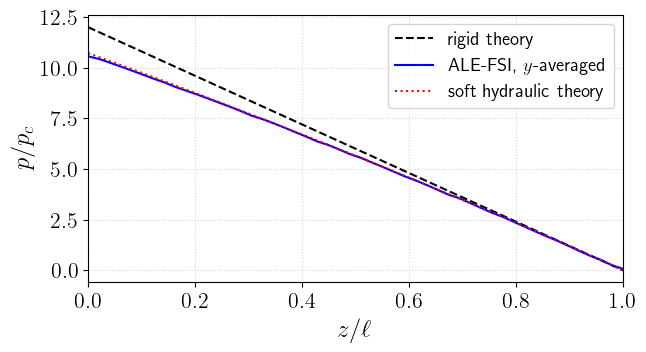

In [201]:
num_x_samples = 50
x_vals = np.linspace(0, l, num_x_samples)
avg_p = []

# Loop over x-values and average over vertical direction
for x_loc in x_vals:
    # Define a narrow vertical strip around x_loc
    strip_width = 1/(2*N)  # something small compared to domain size
    indicator = Expression("fabs(x[0] - x_loc) < w ? 1.0 : 0.0",
                           x_loc=x_loc, w=strip_width, degree=1)
    indicator_func = interpolate(indicator, p.function_space())

    # Compute weighted average
    weighted_integral = assemble(p * indicator_func * dx(FLUID_FLAG))
    area = assemble(indicator_func * dx(FLUID_FLAG))

    avg_p.append(weighted_integral / area if area > DOLFIN_EPS else 0.0)

avg_p = np.array(avg_p)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, pressure_rigid/float(p_c), 
        label='rigid theory', linestyle='dashed', color='black')
ax.plot(x_vals/l, avg_p/float(p_c), 
        label='ALE-FSI, $y$-averaged', color='blue')
ax.plot(x_vals/l, pressure_sh/float(p_c), 
        label='soft hydraulic theory', linestyle='dotted', color='red')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()


## Fluid&ndash;solid interface displacement and pressure

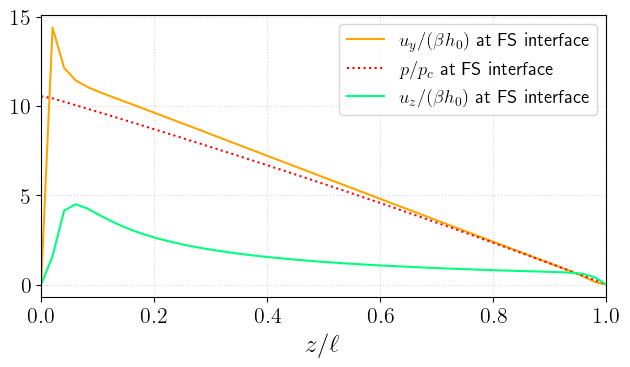

In [202]:
# Create points along the fluid-solid interface:
# (offset down by ~1/N if needed, to ensure we're in the fluid domain)
fs_line_points = [(x, h0) for x in x_vals]

# Evaluate the vertical displacement and pressure at each point:
u_fs_values = []
p_fs_values = []
for point in fs_line_points:
    u_fs_values.append(u(point))
    p_fs_values.append(p(point))

u_fs_values = np.array(u_fs_values)
p_fs_values = np.array(p_fs_values)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, u_fs_values[:,1]/float(beta*h0),
        label=r'$u_y/(\beta h_0)$ at FS interface', color='orange')
ax.plot(x_vals/l, p_fs_values/float(p_c), 
        label='$p/p_c$ at FS interface', color='red', linestyle='dotted')
ax.plot(x_vals/l, u_fs_values[:,0]/float(beta*h0),
        label=r'$u_z/(\beta h_0)$ at FS interface', color='springgreen')

ax.set_xlabel(r'$z/\ell$')
#ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()    

## Pressure contours

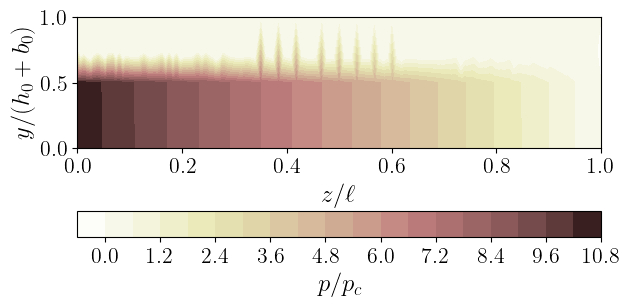

In [203]:
# Get pressure values at vertices:
pressure_values = p.compute_vertex_values(mesh)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, pressure_values/float(p_c), levels=20, cmap='pink_r')
fig.colorbar(contour,label='$p/p_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

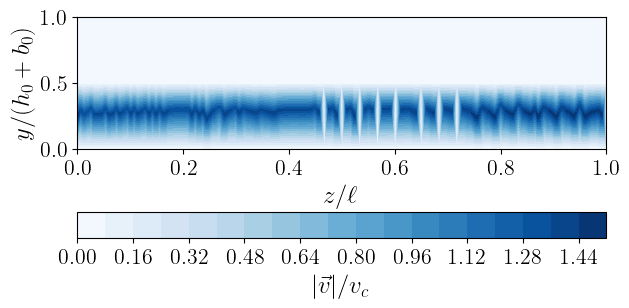

In [204]:
# Get velocity values at vertices:
vx, vy = v.split()
vx_values = vx.compute_vertex_values(mesh)
vy_values = vy.compute_vertex_values(mesh)

# Compute magnitude:
magnitude = np.sqrt(vx_values**2 + vy_values**2)

# Create plot:
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c), levels=20, cmap='Blues')
fig.colorbar(contour,label=r'$|\vec{v}|/v_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.tight_layout()
plt.show()

## Displacement magnitude contours

We can mask all $y/h_0 < h_0/(h_0+b_0)$ to show only the displacement fiend in the solid. There is mesh displacement in the fluid domain but we do not consider that to be "physical."

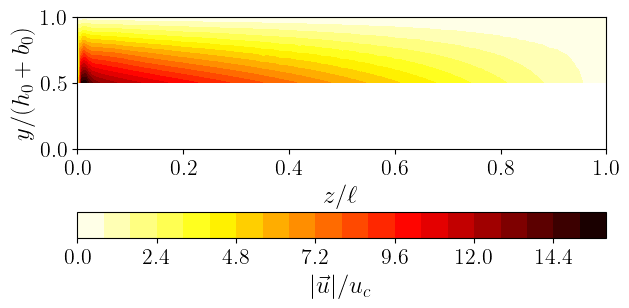

In [210]:
# Get displacement values at vertices:
ux, uy = u.split(True)
ux_values = ux.compute_vertex_values()
uy_values = uy.compute_vertex_values()

# Compute magnitude:
magnitude = np.sqrt(ux_values**2 + uy_values**2)
# Mask off fluid domain, need to deep copy the triang:
masked_triang =  tri.Triangulation(x_coords.copy(), y_coords.copy(), cells.copy())
masked_triang.set_mask(np.mean(y_coords[masked_triang.triangles], axis=1) < h0/(h0+b0))
# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(masked_triang, magnitude/float(beta*h0), levels=20, cmap='hot_r')

fig.colorbar(contour,label=r'$|\vec{u}|/u_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()